In [84]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch_geometric import data

class RecDataset(Dataset):
    def __init__(self, df, num_users, num_items):
        """
        用于 DataLoader 的简单 Dataset, 只返回 (User, pos_item)
        Negative Sampling在训练循环中实时执行，以节省内存
        
        :param df: 说明
        :param num_users: 说明
        :param num_items: 说明
        """
        self.users = torch.LongTensor(df['user_id'].values)
        self.items = torch.LongTensor(df['item_id'].values)
        self.num_users = num_users
        self.num_items = num_items
        
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx]

In [2]:
!pwd

/Users/yunyunai/Desktop/Code_Dir/rec_tutorial/Rec_Project


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

movielens_path = "../Datasets/ml-1m"
p = Path(movielens_path)
for child in p.iterdir():
    print(child)

../Datasets/ml-1m/movies.dat
../Datasets/ml-1m/ratings.dat
../Datasets/ml-1m/README
../Datasets/ml-1m/users.dat


In [5]:
ratings = movielens_path + '/ratings.dat'

df = pd.read_csv(ratings)
df.head()

,1::1193::5::978300760
0,1::661::3::978302109
1,1::914::3::978301968
2,1::3408::4::978300275
3,1::2355::5::978824291
4,1::1197::3::978302268


In [87]:
column_names = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv(ratings, sep='::', names=column_names)
df.head()

/var/folders/d1/b214nt7j03qb1gvsh3tmbpkw0000gn/T/ipykernel_63102/1332009256.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(ratings, sep='::', names=column_names)


,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [88]:
df['user_id'].unique()

array([   1,    2,    3, ..., 6038, 6039, 6040])

In [89]:
# 核心指标统计
n_users = len(df['user_id'].unique())
n_items = len(df['item_id'].unique())
n_interactions = len(df)
n_users, n_items, n_interactions

(6040, 3706, 1000209)

In [90]:
# 稀疏度计算
sparsity = 1 - (n_interactions / (n_users * n_items))
print(f"Sparsity: {sparsity}% ")    # 稀疏度在95%以上，大部分格子是空的

Sparsity: 0.9553163743776871% 


In [91]:
item_counts = df['item_id'].value_counts()
item_counts

item_id
2858    3428
260     2991
1196    2990
1210    2883
480     2672
        ... 
3458       1
2226       1
1815       1
398        1
2909       1
Name: count, Length: 3706, dtype: int64

Text(0, 0.5, 'item popularity')

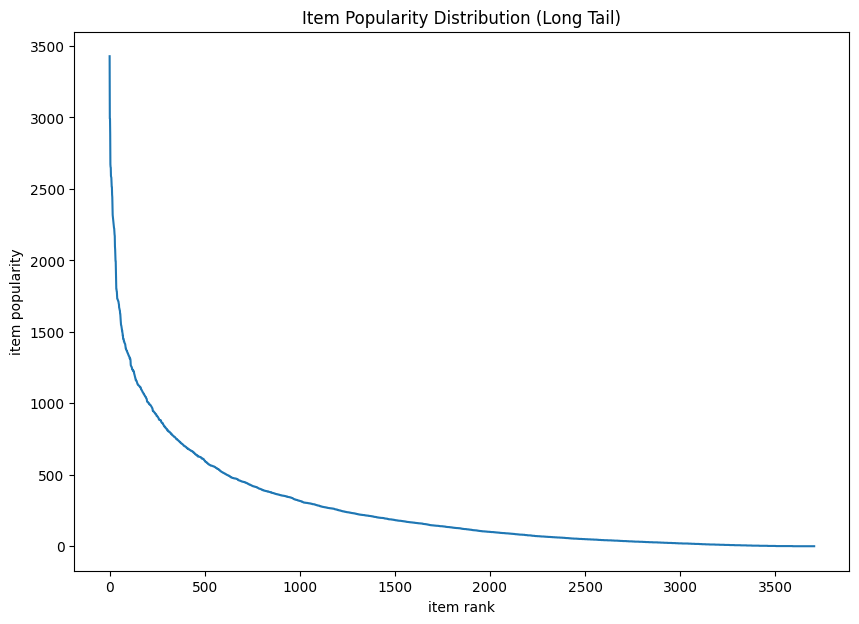

In [92]:
# 长尾分布可视化    (Long-tail Distribution)
plt.figure(figsize=(10, 7))
item_counts = df['item_id'].value_counts()
plt.plot(item_counts.values)
# sns.histplot(item_counts.values, bins=50, kde=True)
plt.title('Item Popularity Distribution (Long Tail)')
plt.xlabel('item rank')
plt.ylabel('item popularity')

Text(0.5, 1.0, 'User Activity Distribution')

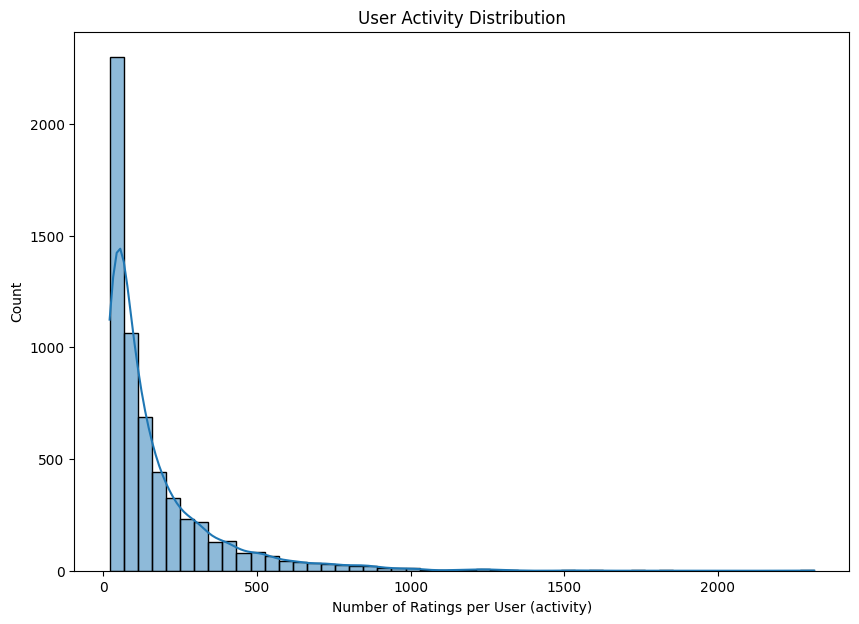

In [93]:
# 用户活跃度分布
plt.figure(figsize=(10, 7))
user_counts = df['user_id'].value_counts()
sns.histplot(user_counts, bins=50, kde=True)    # kde: kernel density estimate
# plt.plot(user_counts.values)
plt.xlabel('Number of Ratings per User (activity)')
plt.title('User Activity Distribution')


In [94]:
# Original Dataframe
df

,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [95]:
# Data Processing
# ID Mapping
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()

# Output numbers of user_id and item_id
print(f"# of interactions: {len(df)}")
print(f"# of users: {df['user_id'].nunique()}")
print(f"# of items: {df['item_id'].nunique()}")

# 将 ID 映射到 0~N-1
df['user_id'] = LE.fit_transform(df['user_id'])
df['item_id'] = LE.fit_transform(df['item_id'])

# 输出转化后的'user_id', 'item_id' 的最大值最小值
print(f"User_id: \nMinimun: {df['user_id'].min()} | Maximum: {df['user_id'].max()}")
print(f"Item_id: \nMinimum: {df['item_id'].min()} | Maximum: {df['item_id'].max()}")

df.head()

# of interactions: 1000209
# of users: 6040
# of items: 3706
User_id: 
Minimun: 0 | Maximum: 6039
Item_id: 
Minimum: 0 | Maximum: 3705


,user_id,item_id,rating,timestamp
0,0,1104,5,978300760
1,0,639,3,978302109
2,0,853,3,978301968
3,0,3177,4,978300275
4,0,2162,5,978824291


In [97]:
# 构建二部图 ID (偏移量处理)
src = df['user_id']
dst = df['item_id'] + (df['user_id'].max() + 1) # df['item_id'] + num_users

dst.min(), dst.max()

(6040, 9745)

In [99]:
# 构建 Edge Index
# PyG 要求 Edge_Index 是 [2, num_edges] 的 LongTensor
import torch

user_tensor = torch.tensor(src, dtype=torch.long)
item_tensor = torch.tensor(dst, dtype=torch.long)

user_tensor, item_tensor

(tensor([   0,    0,    0,  ..., 6039, 6039, 6039]),
 tensor([7144, 6679, 6893,  ..., 6588, 7064, 7065]))

In [100]:
Edge_index = torch.stack([user_tensor, item_tensor], dim=0)
Edge_index.shape, Edge_index

(torch.Size([2, 1000209]),
 tensor([[   0,    0,    0,  ..., 6039, 6039, 6039],
         [7144, 6679, 6893,  ..., 6588, 7064, 7065]]))

In [103]:
# 注意上述 Edge_index 只是单向传播(User->Item)
# 推荐系统中需要双向传播 (user <-> item)
# 当模型需要从 Item 聚合信息回 User 时，此时需要添加反向边 (Item -> User)
from torch_geometric.utils import to_undirected

# to_undirected 会自动处理反向边并去重
Edge_index_undirected = to_undirected(Edge_index)
Edge_index_undirected.shape, Edge_index_undirected

(torch.Size([2, 2000418]),
 tensor([[   0,    0,    0,  ..., 9745, 9745, 9745],
         [6040, 6087, 6184,  ..., 5836, 5926, 5997]]))

In [104]:
# 封装为 PyG.Data 对象
from torch_geometric.data import Data

data = Data(edge_index=Edge_index_undirected)
data

Data(edge_index=[2, 2000418])

In [105]:
# 为 data 附加 Metadata, 方便模型调用 (Q: 一般需要添加哪些 metadata? )

data.num_users = df['user_id'].nunique()
data.num_items = df['item_id'].nunique()
data.num_nodes = data.num_users + data.num_items

data

Data(edge_index=[2, 2000418], num_users=6040, num_items=3706, num_nodes=9746)

In [17]:
ratings = movielens_path + '/ratings.dat'
column_names = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv(ratings, sep='::', names=column_names)

df, df.describe()

/var/folders/d1/b214nt7j03qb1gvsh3tmbpkw0000gn/T/ipykernel_5387/1675394056.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(ratings, sep='::', names=column_names)


(         user_id  item_id  rating  timestamp
 0              1     1193       5  978300760
 1              1      661       3  978302109
 2              1      914       3  978301968
 3              1     3408       4  978300275
 4              1     2355       5  978824291
 ...          ...      ...     ...        ...
 1000204     6040     1091       1  956716541
 1000205     6040     1094       5  956704887
 1000206     6040      562       5  956704746
 1000207     6040     1096       4  956715648
 1000208     6040     1097       4  956715569
 
 [1000209 rows x 4 columns],
             user_id       item_id        rating     timestamp
 count  1.000209e+06  1.000209e+06  1.000209e+06  1.000209e+06
 mean   3.024512e+03  1.865540e+03  3.581564e+00  9.722437e+08
 std    1.728413e+03  1.096041e+03  1.117102e+00  1.215256e+07
 min    1.000000e+00  1.000000e+00  1.000000e+00  9.567039e+08
 25%    1.506000e+03  1.030000e+03  3.000000e+00  9.653026e+08
 50%    3.070000e+03  1.835000e+03  4.0

In [19]:
num_users = df['user_id'].nunique()
num_items = df['item_id'].nunique()

num_users, num_items

(6040, 3706)

In [15]:
import torch
import pandas as pd
from torch_geometric.utils import to_undirected
from sklearn.preprocessing import LabelEncoder

def df_to_edge_index(df: pd.DataFrame,
                     user_col: str = "user_id",
                     item_col: str = "item_id",
                     rating_col: str = None,
                     threshold: float = 0):
    """
    Turn User-Item interactions/ratings dataframe into Edge_Index
    
    params:
        - df: Original Dataframe
        - user_col: the column name of user_id
        - item_col: the colomn name of item_id
        - rating_col(optional): the colomn name of ratings; if None, treat as implicit feedback(出现的user-item都视为一次正向交互)
        - threshold: the rating threshold, turn explicit features into implicit features
    
    Returns:
        - result (dict): 
            - edge_index (torch.LongTensor): [2, num_edges] undirected bipartite graph edges index
            - num_users (int): the numbers of users
            - num_items (int): the numbers of items
            - user_mapping (LabelEncoder): User_id Encoder
            - item_mapping (LabelEncoder): Item_id Encoder
    """
    
    # 1. Filtering data (如果有评分和阈值要求)
    if (rating_col is not None and threshold is not None):
        print(f"Filtering data: keeping interactions where {rating_col} >= {threshold}")
        df_filtered = df[df[rating_col] >= threshold].copy(deep=True)
    else:
        df_filtered = df.copy(deep=True)
    
    print(f"Processing {len(df_filtered)} interactions...")
    
    # 2. ID Mapping
    user_le = LabelEncoder()
    item_le = LabelEncoder()
    
    # Fit(learn dict): 使用全局原始数据(df)
    user_le.fit(df[user_col])
    item_le.fit(df[item_col])
    
    # Transform(transform data): 应用到过滤后的数据(df_filtered)
    user_ids = user_le.transform(df_filtered[user_col])
    item_ids = item_le.transform(df_filtered[item_col])
    
    
    num_users = len(user_le.classes_)
    num_items = len(item_le.classes_)
    
    # 3.构建 PyTorch张量和索引偏移处理
    # Source Node/User Node: (0, num_user - 1)
    src = torch.tensor(user_ids, dtype=torch.long)
    
    # Destination Node/Item Node: (num_user, n_item + num_user - 1)
    dst = torch.tensor(item_ids + num_users, dtype=torch.long)
    
    # 4. 构建 user-> item 单向边
    # shape: [2, num_iteractions]
    edge_index_user_to_item = torch.stack([src, dst], dim=0)
    
    # 5. 转为无向图 (user <-> item)
    # shape: [2, 2*num_iteractions]
    edge_index = to_undirected(edge_index_user_to_item)
    
    return {
        "edge_index": edge_index,
        "num_users": num_users,
        "num_items": num_items,
        "num_nodes": num_users + num_items,
        "user_map": user_le,
        "item_map": item_le
    }
    

result = df_to_edge_index(df=df, rating_col="rating", threshold=3.5)
result

/var/folders/d1/b214nt7j03qb1gvsh3tmbpkw0000gn/T/ipykernel_5387/381388534.py:82: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(ratings, sep='::', names=column_names)


Filtering data: keeping interactions where rating >= 3.5
Processing 575281 interactions...


{'edge_index': tensor([[   0,    0,    0,  ..., 9745, 9745, 9745],
         [6040, 6087, 6184,  ..., 5811, 5836, 5997]]),
 'num_users': 6040,
 'num_items': 3706,
 'num_nodes': 9746,
 'user_map': LabelEncoder(),
 'item_map': LabelEncoder()}

In [38]:
import torch
import pandas as pd
from torch_geometric.utils import to_undirected
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

def df_to_edge_index(df: pd.DataFrame,
                     user_col: str = "user_id",
                     item_col: str = "item_id",
                     rating_col: str = None,
                     threshold: float = 0,
                     test_size: float = 0.2):
    """
    Turn User-Item interactions/ratings dataframe into Edge_Index
    
    params:
        - df: Original Dataframe
        - user_col: the column name of user_id
        - item_col: the colomn name of item_id
        - rating_col(optional): the colomn name of ratings; if None, treat as implicit feedback(出现的user-item都视为一次正向交互)
        - threshold: the rating threshold, turn explicit features into implicit features
    
    Returns:
        - result (dict):
            - train_df: 用于DataLoader负采样
            - test_dict: 用于评估指标计算 
            - edge_index (torch.LongTensor): [2, num_edges] undirected bipartite graph edges index
            - num_users (int): the numbers of users
            - num_items (int): the numbers of items
            - user_mapping (LabelEncoder): User_id Encoder
            - item_mapping (LabelEncoder): Item_id Encoder
    """
    
    # 1. Filtering data (如果有评分和阈值要求)
    if (rating_col is not None and threshold is not None):
        print(f"Filtering data: keeping interactions where {rating_col} >= {threshold}")
        df_filtered = df[df[rating_col] >= threshold].copy(deep=True)
    else:
        df_filtered = df.copy(deep=True)
        
    # --- Fix: 过滤掉交互太少的用户 (Cold Start) ---
    # Stratified K-Fold/Split 至少需要每个 User 有 2 条以上记录 (1 Train, 1 Test)
    # 为了保证 Test 集中有足够数据计算 Metric，通常建议保留 5 条以上
    min_items = 5
    user_counts = df_filtered[user_col].value_counts()
    valid_users = user_counts[user_counts >= min_items].index
    
    # 仅保留有效用户
    df_filtered = df_filtered[df_filtered[user_col].isin(valid_users)].copy()
    print(f"Filtered low interaction users (<{min_items}). Final interactions: {len(df_filtered)}")
    # ---------------------------------------------
    
    print(f"Processing {len(df_filtered)} interactions...")
    
    # 2. ID Mapping
    user_le = LabelEncoder()
    item_le = LabelEncoder()
    
    # Fit(learn dict): 使用全局原始数据(df) -> 改为使用过滤后的数据，避免ID空洞
    # 注意：如果想保留原始所有ID的映射，可以用 df。但在 GNN 中通常只映射活跃节点。
    # 这里我们只对过滤后剩下的 User/Item 进行重新编号，保证 ID 连续且从0开始
    user_le.fit(df_filtered[user_col])
    item_le.fit(df_filtered[item_col])
    
    # Transform(transform data): 应用到过滤后的数据(df_filtered)
    # user_ids = user_le.transform(df_filtered[user_col])
    # item_ids = item_le.transform(df_filtered[item_col])
    
    
    num_users = len(user_le.classes_)
    num_items = len(item_le.classes_)
    
    print("Splitting train/test set (80/20)...")
    
    # startify=df_filtered['user_ids] 保证每个用户的 80% 数据进入 train, 20% 进入test
    # random_state 固定种子，保证复现性
    train_df, test_df = train_test_split(
        df_filtered,
        test_size=test_size,
        random_state=42,
        stratify=df_filtered[user_col]
    )
    
    # 构建edge_index
    # 注意：我们要用 train_df 来构建图结构 (Message Passing)，而不是全量数据！
    # 这样防止 Test Set 的边泄露给 Training
    # 重新在 Train_DF 上做 Transform 拿到 ID (前面已经Fit过了)
    train_user_ids = user_le.transform(train_df[user_col])
    train_item_ids = item_le.transform(train_df[item_col])
    
    user_tensor = torch.tensor(train_user_ids, dtype=torch.long)
    item_tensor = torch.tensor(train_item_ids + num_users, dtype=torch.long)
    
    edge_user_to_item = torch.stack([user_tensor, item_tensor], dim=0)
    edge_index = to_undirected(edge_user_to_item)
    
    # 打包测试集 (用于 Evaluation)
    # 将测试集整理成字典形式: {user_id: [item_id1, item_id2, ...]}
    # 方便计算 Recall/NDCG 时快速查找 Ground Truth
    test_dict = test_df.groupby(user_col)[item_col].apply(list).to_dict()
    
    return {
        "train_df": train_df,  
        "test_dict": test_dict,
        "edge_index": edge_index, # 仅包含训练集互动的图
        "num_users": num_users,
        "num_items": num_items,
        "num_nodes": num_users + num_items,
        "user_map": user_le,
        "item_map": item_le
    }
    

result = df_to_edge_index(df=df, rating_col="rating", threshold=3, test_size=0.2)
len(result['train_df']), len(result['test_dict'])

Filtering data: keeping interactions where rating >= 3
Filtered low interaction users (<5). Final interactions: 836477
Processing 836477 interactions...
Splitting train/test set (80/20)...


(669181, 6038)

### LightGCN

* 图卷积层

    * 对于user节点u:
        $$
        e_u^{(k + 1)} = \sum_{i\in N_u}\frac{1}{\sqrt{\Vert N_u\Vert}\sqrt{\Vert N_i\Vert}} e_i^{(k)}
        $$

    * 对于item节点i:
        $$
        e_i^{(k + 1)} = \sum_{i\in N_i}\frac{1}{\sqrt{\Vert N_i\Vert}\sqrt{\Vert N_u\Vert}} e_u^{(k)}
        $$
    * 在实现时将$e_i$和$e_u$都视作$e$，更新同时进行，上述更新完整的矩阵形式如下：
        $$
            E^{(k + 1)} = \hat{A}^{(k)} \times E^{(k)}
        $$
        * 其中$E^{(k)}$是一个[N_users + N_times, dim]的嵌入矩阵
        * $\hat{A} = D^{-\frac{1}{2}}AD^{-\frac{1}{2}}$是归一化后的邻接矩阵
        * 乘以邻接矩阵就是在取邻居

* Edge Index(没理解)
  * 查表更新
        $$ 
        E_{k+1}[target] += E_{k}[source]\times \text{weight}
        $$

In [25]:
import torch
from torch_geometric.nn.conv import LGConv
from torch import nn

class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, num_layers=3, embedding_dim=64):
        super().__init__()
        
        self.num_users = num_users
        self.num_items = num_items
        self.num_layers = num_layers
        self.num_nodes = self.num_users + self.num_items
        
        # 1. Initialize Embedding
        # 将[users|items]放在同一个Embedding表中，方便统一进行图传播
        self.embedding_layer = nn.Embedding(num_embeddings=self.num_nodes,
                                            embedding_dim=embedding_dim)
        
        # 2. Initialize LightGCN ConvLayer
        self.conv_layers = nn.ModuleList([
            LGConv() for _ in range(num_layers)
        ])  # [Conv_0, Conv_1, Conv_2]
        # WANT: E_final = Mean(E_0, E_1, E_2,...E_n)
        
        # 3. Initialize Parameters (important to converge speed)
        self.init_params()
        
    def init_params(self):
        # Using Normal Distribution Initialize
        nn.init.normal_(self.embedding.weight, std=0.1)
        
    def forward(self, edge_index):
        """
        前向传播，获得Embedding
        """
        # 1. original embedding
        x = self.embedding.weight
        
        # 保存每一层的 Embedding，后续做加权和
        all_embeddings = [x]    # E_0 = x
        
        # 2. 图卷积传播/Message Passing
        for conv in self.conv_layers:
            # LGConv内部自动归一化邻接矩阵 - https://pytorch-geometric.readthedocs.io/en/2.5.1/generated/torch_geometric.nn.conv.LGConv.html
            x = conv(x, edge_index) # E'[target] = E[source]*weight (weight=归一化系数)
            all_embeddings.append(x)
        
        # 3. 层级组合/Aggregation
        # 将第 0 层，第 1 层, ... 第 K 层的特征/Embedding加起来(权重为1)求平均
        # 这样既保留了原始特征，又利用了高阶邻居信息
        # stack shape: [num_layers + 1, num_nodes, num_embedding_dim]
        all_embeddings = torch.stack(all_embeddings, dim=0)
        
        # 取平均，得到每个节点最终的 Embedding
        final_embeddings = torch.mean(all_embeddings, dim=0)
        
        # 4. 拆分回 User 和 Item
        # 根据 ID 范围进行切片
        user_emb, item_emb = final_embeddings[:self.num_users], final_embeddings[self.num_users:]
        
        return user_emb, item_emb
    
    def recommend(self, user_indices, edge_index, k=10):
        """Inference"""
        # 获取最终训练好的 user_emb 和 item_emb
        user_emb_final, item_emb_final = self.forward(edge_index)
        
        # 选出指定 ID 的 users
        target_user = user_emb_final[user_indices]  # [batch, dim]
        
        # 计算分数 (点积) [batch, dim] @ [num_item, dim].T -> [batch, num_item]
        scores = target_user @ item_emb_final.T
        
        # 取 Top-K
        _, topk_items = torch.topk(scores, k=k) # [batch, k]
        
        return topk_items
    
    def get_initial_embeddings(self, indices):
        """专门用于正则化的helper function: 获取指定索引的第0层Embedding"""
        return self.embedding_layer(indices)    # 查表

### Bayesian Personalized Ranking (BPR) Loss
> BPR Loss 不关心预测出来的具体分数，而关心 “当前预测节点和正样本的分数 是否比 其和负样本的分数 高”，这个差值越高越好。

$$
\text{Loss} = - \sum_{(u, i, j)\in D} \ln \sigma (\hat{y}_{ui} - \hat{y}_{uj})
$$


* BPR Loss的训练数据不是单个对象，而是一个三元组(u,i,j):
  * u: 用户(User)
  * i: 正样本物品(Positive Item, 用户交互过的)
  * j: 负样本物品(Negative Item, 用户未交互过的/随机抽取的)
